In [1]:
from mainfunc import *
from Utils.plotting_functions import *
from Worlds.World import World
import Drone.Simulation

parameters = load_parameters("Settings/simulation_parameters.yaml")
init_state = create_initial_state()
thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

In [2]:
waypoints = [
    {"x": 0, "y": 0, "z": 0, "v": 5},
    {"x": 50, "y": 0, "z": 50, "v": 5},
    {"x": 1000, "y": 1000, "z": 10, "v": 5},
]

In [3]:
sim = Simulation(
    drone,
    world,
    waypoints, 
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=True,
    noise_annoyance_radius=9,
)
sim.startSimulation(stop_at_target=True, use_static_target=True, verbose=True)
costs = calculate_costs(sim, parameters['simulation_time'])
print(f"Total costs: {costs}")

Final target reached at time: 110.58 s
Simulation completed in 19.47 seconds.
Total costs: {'total_cost': 1570.2387895119568, 'time_cost': 110.584, 'final_distance_cost': 1.8143533289454512, 'oscillation_cost': 5.978225975970089, 'completition_cost': 0.0, 'overshoot_cost': 1425.3179318756536, 'power_cost': 10.209184936523439, 'noise_cost': 16.335093394864312, 'n_waypoints_completed': 3, 'tot_waypoints': 3}


In [4]:
waypoints_list = [(x,y,z) for x,y,z in [(wp['x'], wp['y'], wp['z']) for wp in waypoints]]
del waypoints_list[-1]

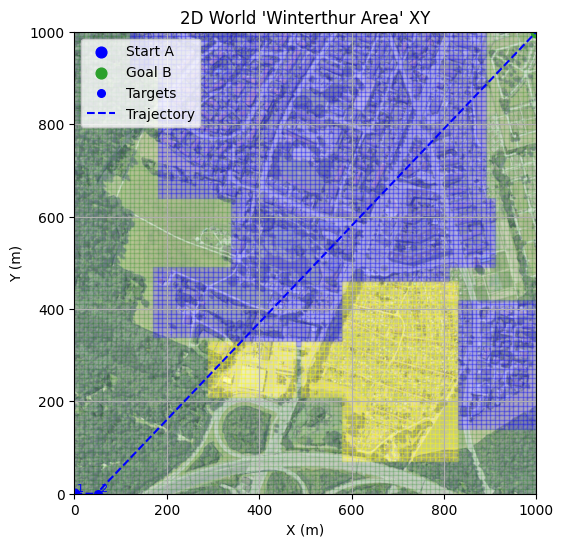

In [5]:
show2DWorld(
    world, sim.positions, waypoints[0], waypoints[-1], waypoints_list)
